In [5]:
import pandas as pd

In [6]:
df=pd.read_csv('spam_ham_dataset.csv')
df.head(n=5)

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [6]:
df.shape

(5171, 4)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  5171 non-null   int64
 1   label       5171 non-null   str  
 2   text        5171 non-null   str  
 3   label_num   5171 non-null   int64
dtypes: int64(2), str(2)
memory usage: 5.3 MB


In [18]:
df['text']=df['text'].str.replace('Subject:','')

In [14]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,: enron methanol ; meter # : 988291\r\nthis is...,0
1,2349,ham,": hpl nom for january 9 , 2001\r\n( see attach...",0
2,3624,ham,": neon retreat\r\nho ho ho , we ' re around to...",0
3,4685,spam,": photoshop , windows , office . cheap . main ...",1
4,2030,ham,: re : indian springs\r\nthis deal is to book ...,0


In [7]:
import re
df['text'] = df['text'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

In [20]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,enron methanol meter 988291\r\nthis is a f...,0
1,2349,ham,hpl nom for january 9 2001\r\n see attached ...,0
2,3624,ham,neon retreat\r\nho ho ho we re around to th...,0
3,4685,spam,photoshop windows office cheap main trend...,1
4,2030,ham,re indian springs\r\nthis deal is to book th...,0


In [8]:
df['text'] = df['text'].str.replace(r'[\r\n]+', ' ', regex=True)

In [22]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,enron methanol meter 988291 this is a foll...,0
1,2349,ham,hpl nom for january 9 2001 see attached fil...,0
2,3624,ham,neon retreat ho ho ho we re around to that ...,0
3,4685,spam,photoshop windows office cheap main trend...,1
4,2030,ham,re indian springs this deal is to book the t...,0


In [28]:
pip uninstall nltk -y

Found existing installation: nltk 3.9.4
Uninstalling nltk-3.9.4:
  Successfully uninstalled nltk-3.9.4
Note: you may need to restart the kernel to use updated packages.


In [29]:
pip install nltk


  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [16]:
import nltk
from nltk.corpus  import stopwords

nltk.download('stopwords')
stop_words=set(stopwords.words('english'))

def clean_text(text):
    # Remove Subject: or subject: or just Subject/subject (case-insensitive)
    text = re.sub(r'\bsubject\s*:?\s*', '', text, flags=re.IGNORECASE)
    # Remove special characters, keep only letters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_text']=df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\subra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
df.head()

,Unnamed: 0,label,text,label_num,clean_text
0,605,ham,Subject enron methanol meter 988291 this is...,0,enron methanol meter follow note gave monday p...
1,2349,ham,Subject hpl nom for january 9 2001 see attac...,0,hpl nom january see attached file hplnol xls h...
2,3624,ham,Subject neon retreat ho ho ho we re around t...,0,neon retreat ho ho ho around wonderful time ye...
3,4685,spam,Subject photoshop windows office cheap mai...,1,photoshop windows office cheap main trending a...
4,2030,ham,Subject re indian springs this deal is to boo...,0,indian springs deal book teco pvr revenue unde...


In [21]:
df['label'].value_counts()

label
ham     3672
spam    1499
Name: count, dtype: int64

In [22]:
import seaborn as sns
import  matplotlib.pyplot as plt

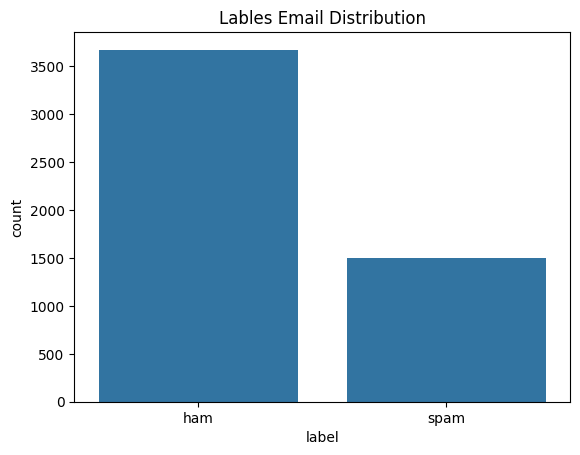

In [ ]:
sns.countplot(x='label',data=df)
plt.title(' Email Distribution')
plt.show()

In [28]:
# Now we have to do ham and spam equal
ham_email=df[df['label']=='ham']
spam_email=df[df['label']=='spam']

## Downgrade the ham email data
ham_email_downgrade=ham_email.sample(n=len(spam_email),random_state=42)
balanced_data=pd.concat([ham_email_downgrade,spam_email])
df=balanced_data.sample(frac=1,random_state=42).reset_index(drop=True)

In [29]:
df['label'].value_counts()

label
ham     1499
spam    1499
Name: count, dtype: int64

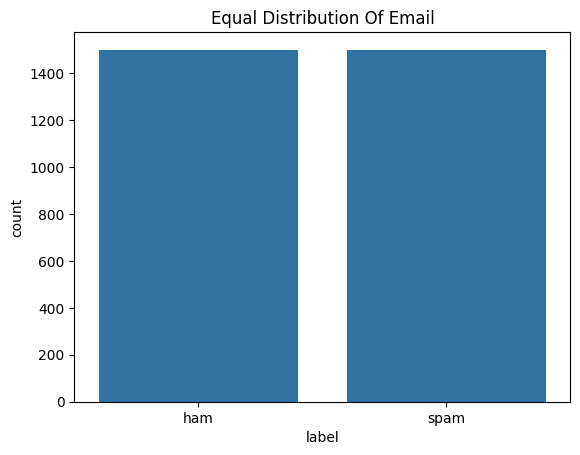

In [31]:
sns.countplot(x='label',data=df)
plt.title("Equal Distribution Of Email")

plt.show()

In [34]:
## Now we have to do word counts cause we can see which word mostly used in spam mail and in ham mail aswell
from wordcloud import WordCloud

def plot_wordcloud(text,title):
   wordCloud=WordCloud(background_color='black',height=400,width=800).generate(text)
   plt.figure(figsize=(10, 5))
   plt.imshow(wordCloud, interpolation='bilinear')
   plt.axis('off')
   plt.title(title)
   plt.show()




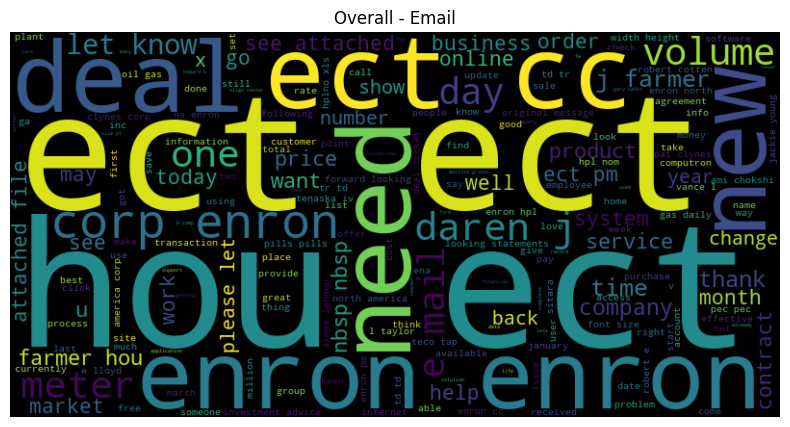

In [35]:
# Displaying  both spam and ham emial frequent words
plot_wordcloud(' '.join(df['clean_text']), 'Overall - Email')

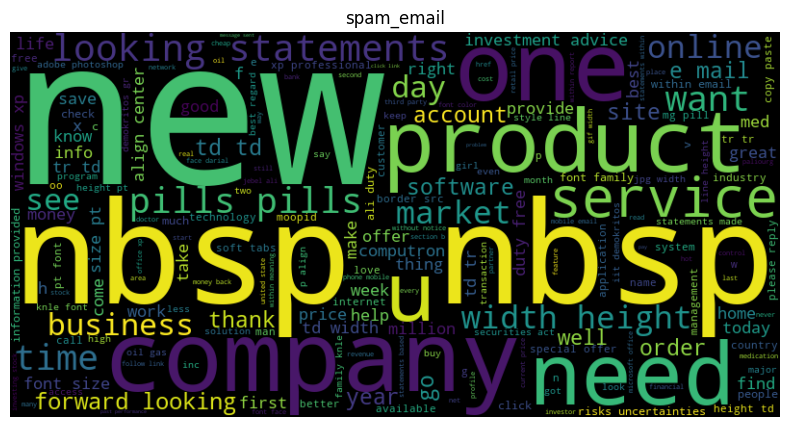

In [36]:
# Spam Email
plot_wordcloud(' '.join(df[df['label']=='spam']['clean_text']),'spam_email')

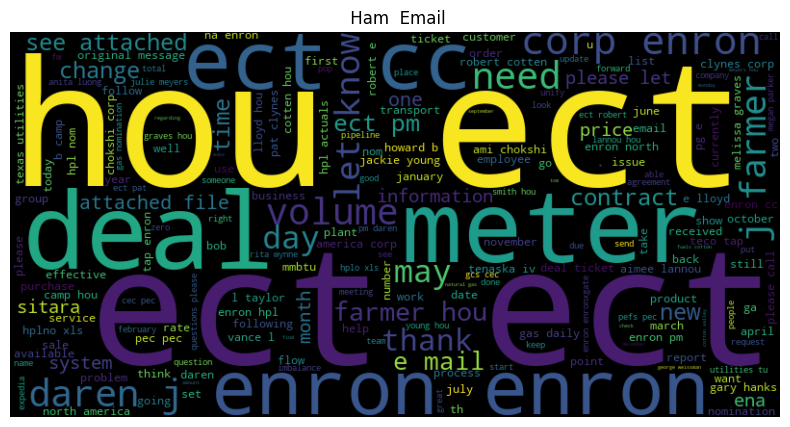

In [37]:
## Displaying ham emails
plot_wordcloud(' '.join(df[df['label']=='ham']['clean_text']),' Ham  Email')

In [51]:
# Now the time is train the model and conversion of clean text  column into integer so that machine learning model can understand
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
import joblib

In [40]:
# Separating th input and output data
# converting  text to number
tfidf=TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(df['clean_text'])  # convering text to binary
y=df['label']

In [43]:
# Train the model
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
spam_model=LogisticRegression(max_iter=1000)
spam_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
y_pred=spam_model.predict(X_test)

In [ ]:
y_pred

In [49]:
#  Model Evaluation
print("Confusion matrix:-",confusion_matrix(y_pred,y_test))
print("Classification report:-",classification_report(y_pred,y_test))

Confusion matrix:- [[287   0]
 [ 13 300]]
Classification report:-               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       287
        spam       1.00      0.96      0.98       313

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



In [52]:
accuracy=accuracy_score(y_pred,y_test)

In [53]:
accuracy

0.9783333333333334

In [54]:
# Save the model
joblib.dump(spam_model,"emai_Spam_detection.pkl")
joblib.dump(tfidf,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [55]:
import joblib

# Save the model and vectorizer
joblib.dump(spam_model, 'email_spam_model.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

print("✅ Models saved successfully!")
print("✅ email_spam_model.joblib saved")
print("✅ tfidf_vectorizer.joblib saved")

✅ Models saved successfully!
✅ email_spam_model.joblib saved
✅ tfidf_vectorizer.joblib saved
